## ***árbolKD***


In [ ]:
import math
import matplotlib.pyplot as plt
import random


# Nodo del KD-Tree

class Nodo:
    def __init__(self, punto, eje):
        self.punto = punto      # lista o tupla
        self.eje = eje          # dimension para dividir
        self.izq = None         # rama izquierdo
        self.der = None         # rama lado derecho





def construir(puntos, profundidad=0):
    """
    Construye un KD-Tree a partir de una lista de puntos de k dimensiones
    """

    # Caso base
    if not puntos:
        return None

    k = len(puntos[0])  # número de dimensiones
    eje = profundidad % k  # alternar dimensión

    # ordenar puntos
    puntos.sort(key=lambda p: p[eje])

    # mediana
    m = len(puntos) // 2

    """ ordenamos los puntos según la dimensión actual y tomamos el elemento centra,
     esto garantiza obtener la mediana en ese eje, independientemente de la distribución.
     sin embargo, aunque el árbol queda balanceado en número de nodos,
     no garantiza una partición espacial homogénea si los datos están distribuidos de forma irregular.
    """

    # Crear nodo
    nodo = Nodo(puntos[m], eje)

    # Construir subárboles (siguiente nivel → profundidad +1)
    nodo.izq = construir(puntos[:m], profundidad + 1)
    nodo.der = construir(puntos[m+1:], profundidad + 1)

    return nodo



# Distancia euclidiana en k dimensiones

def distancia(a, b):
    """
    Calcula la distancia entre dos puntos de k dimensiones
    """
    return math.sqrt(sum((a[i] - b[i])**2 for i in range(len(a))))



# Búsqueda por rango (radio)

def buscar_radio(nodo, objetivo, radio, resultado):
    """
    Encuentra todos los puntos dentro de un radio dado
    """

    if nodo is None:
        return

    # Si el punto actual está dentro del radio → guardarlo
    if distancia(nodo.punto, objetivo) <= radio:
        resultado.append(nodo.punto)

    eje = nodo.eje

    # Diferencia en la dimensión actual
    diff = objetivo[eje] - nodo.punto[eje]

    # Explorar primero el lado más probable
    if diff <= 0:
        buscar_radio(nodo.izq, objetivo, radio, resultado)
    else:
        buscar_radio(nodo.der, objetivo, radio, resultado)


    # Solo exploramos el otro lado si el radio cruza el plano de división
    if abs(diff) <= radio:
        if diff <= 0:
            buscar_radio(nodo.der, objetivo, radio, resultado)
        else:
            buscar_radio(nodo.izq, objetivo, radio, resultado)



# más cercano
def mas_cercano(nodo, objetivo, mejor=None):
    """
    Encuentra el punto más cercano al objetivo
    """

    if nodo is None:
        return mejor

    # Distancia del punto actual
    d = distancia(nodo.punto, objetivo)

    # Actualizar mejor si encontramos uno más cercano
    if mejor is None or d < distancia(mejor, objetivo):
        mejor = nodo.punto

    eje = nodo.eje
    diff = objetivo[eje] - nodo.punto[eje]

    # Elegir qué lado explorar primero
    if diff <= 0:
        primero = nodo.izq
        segundo = nodo.der
    else:
        primero = nodo.der
        segundo = nodo.izq

    # Explorar el lado más prometedor
    mejor = mas_cercano(primero, objetivo, mejor)

    # PODA:
    # Solo explorar el otro lado si podría haber un punto más cercano
    if abs(diff) < distancia(mejor, objetivo):
        mejor = mas_cercano(segundo, objetivo, mejor)

    return mejor




## ***EJEMPLO DE USO***


In [ ]:

if __name__ == "__main__":


    # Generar 10,000 puntos aleatorios (x, y)

    puntos = [
        (random.uniform(-10000, 10000), random.uniform(-10000, 10000))
        for _ in range(10000)
    ]

    print("Total de puntos:", len(puntos))


    # Construir árbol

    raiz = construir(puntos)

    print("Árbol construido")


    # Punto objetivo (también aleatorio)

    objetivo = (random.uniform(-10000, 10000), random.uniform(-10000, 10000))

    print("Punto objetivo:", objetivo)


    # Búsqueda por radio (ej: 500 metros)

    resultado = []
    buscar_radio(raiz, objetivo, radio=500, resultado=resultado)

    print("Cantidad de puntos en radio:", len(resultado))


    # Vecino más cercano

    cercano = mas_cercano(raiz, objetivo)

    print("Punto más cercano:", cercano)
    print("Distancia al más cercano:", distancia(cercano, objetivo))

Total de puntos: 10000
Árbol construido
Punto objetivo: (559.0557783763161, -123.9159495144977)
Cantidad de puntos en radio: 21
Punto más cercano: (639.4870657568008, -275.6193852671604)
Distancia al más cercano: 171.70650660019956


## ***GRÁFICOS EN R2***





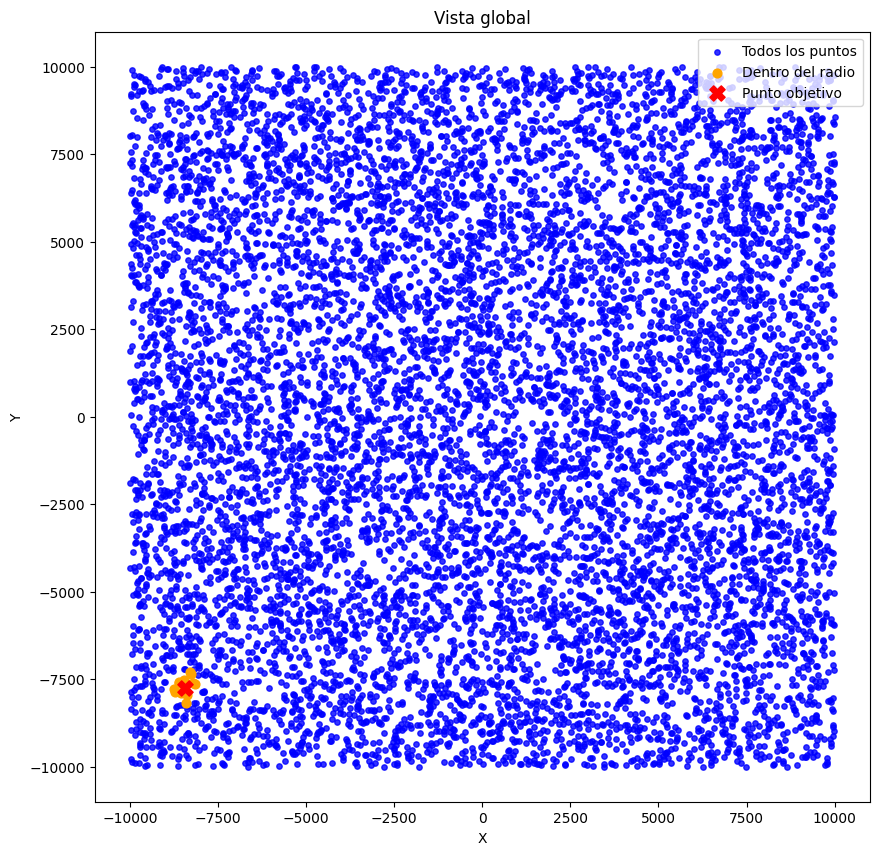

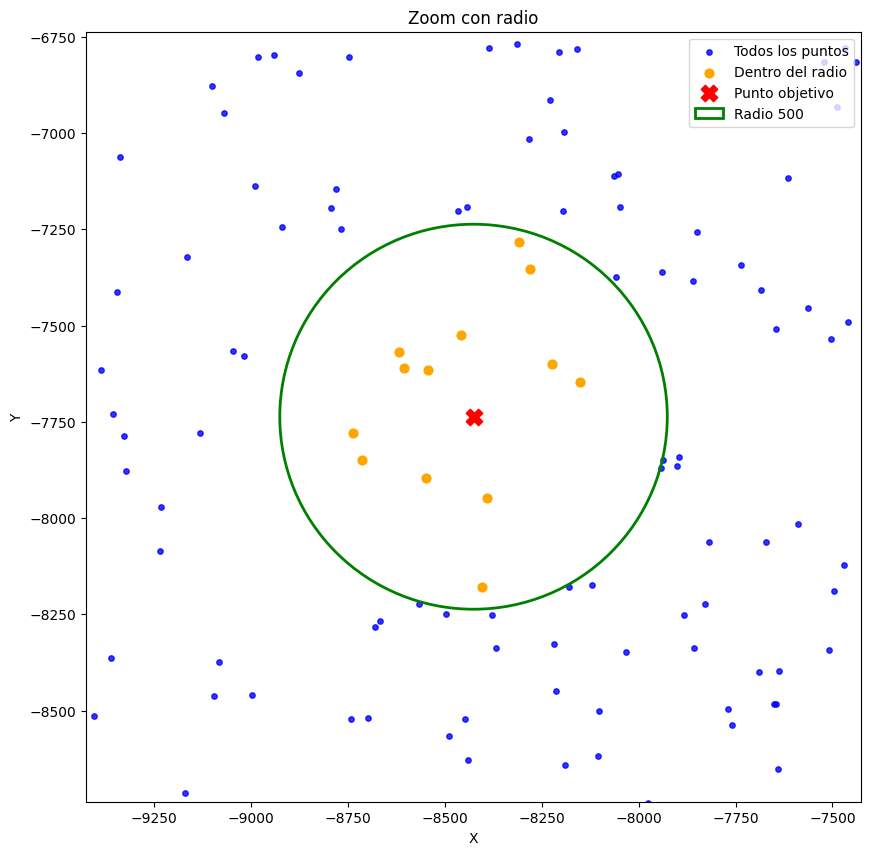

In [ ]:
    # Preparar datos para graficar
    x_all = [p[0] for p in puntos]
    y_all = [p[1] for p in puntos]

    x_cerca = [p[0] for p in resultado]
    y_cerca = [p[1] for p in resultado]


    # Gráfica global
    plt.figure(figsize=(10, 10))

    plt.scatter(x_all, y_all, s=15, color='blue', alpha=0.8, label='Todos los puntos')
    plt.scatter(x_cerca, y_cerca, s=40, color='orange', label='Dentro del radio')
    plt.scatter(objetivo[0], objetivo[1], s=120, color='red', marker='X', label='Punto objetivo')

    plt.legend(loc='upper right')
    plt.title("Vista global")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


    # Gráfica con zoom
    plt.figure(figsize=(10, 10))

    plt.scatter(x_all, y_all, s=15, color='blue', alpha=0.8, label='Todos los puntos')
    plt.scatter(x_cerca, y_cerca, s=40, color='orange', label='Dentro del radio')
    plt.scatter(objetivo[0], objetivo[1], s=140, color='red', marker='X', label='Punto objetivo')

    # Dibujar radio
    circulo = plt.Circle(objetivo, 500, fill=False, color='green', linewidth=2, label='Radio 500')
    plt.gca().add_patch(circulo)

    # Zoom alrededor del punto
    plt.xlim(objetivo[0] - 1000, objetivo[0] + 1000)
    plt.ylim(objetivo[1] - 1000, objetivo[1] + 1000)

    plt.legend(loc='upper right')
    plt.title("Zoom con radio")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

## ***ÁRBOL PRIMEROS 4 NIVELES***


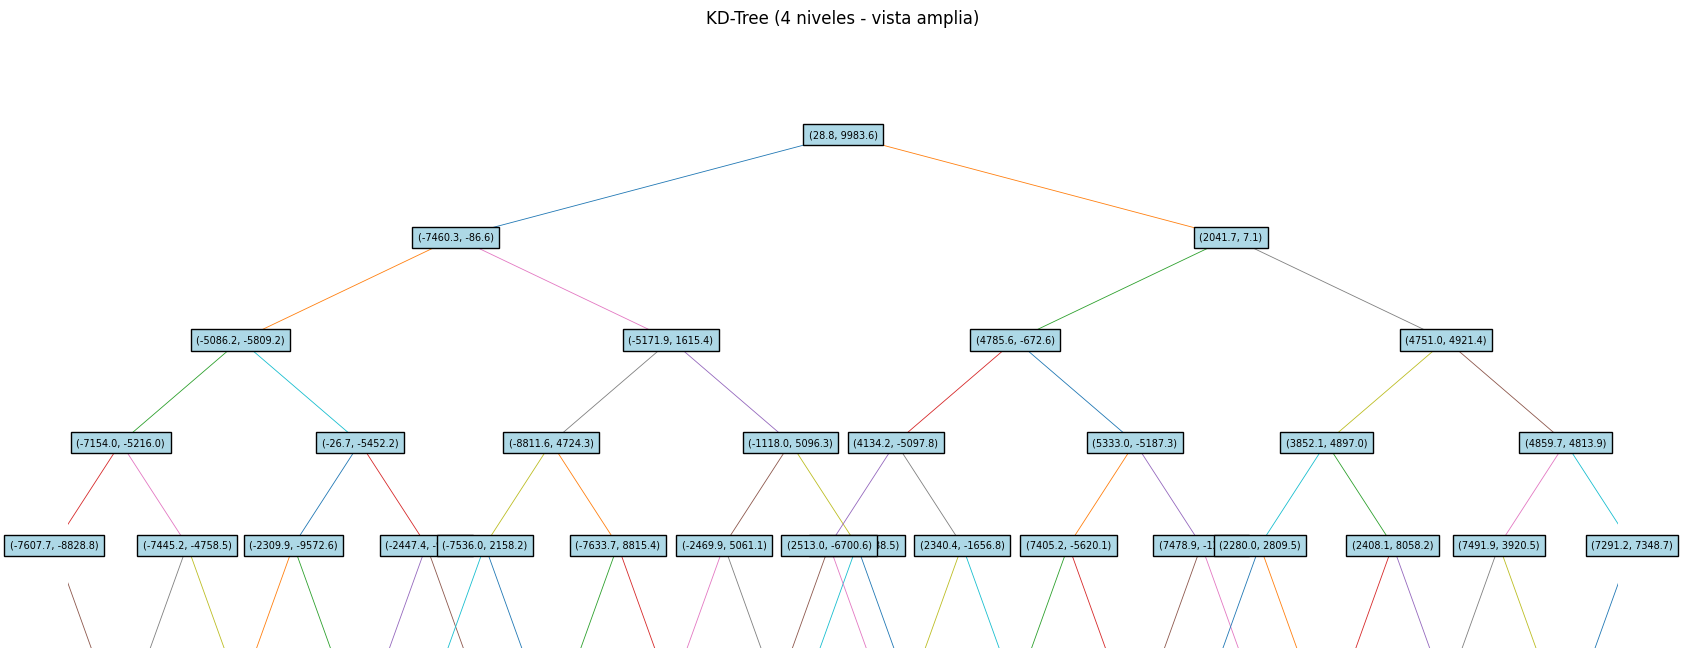

In [ ]:

class Nodo:
    def __init__(self, punto, eje):
        self.punto = punto
        self.eje = eje
        self.izq = None
        self.der = None


def construir(puntos, profundidad=0):
    if not puntos:
        return None

    k = len(puntos[0])
    eje = profundidad % k

    puntos.sort(key=lambda p: p[eje])
    m = len(puntos) // 2

    nodo = Nodo(puntos[m], eje)
    nodo.izq = construir(puntos[:m], profundidad + 1)
    nodo.der = construir(puntos[m+1:], profundidad + 1)

    return nodo



# GRAFICAR MÁS ANCHO

def graficar_arbol(raiz, max_niveles=4):

    # figura MUCHO más ancha
    fig, ax = plt.subplots(figsize=(20, 8))

    def dibujar(nodo, x, y, dx, nivel):
        if nodo is None or nivel > max_niveles:
            return

        texto = f"({round(nodo.punto[0],1)}, {round(nodo.punto[1],1)})"

        ax.text(x, y, texto,
                ha='center', va='center',
                fontsize=7,
                bbox=dict(facecolor='lightblue', edgecolor='black'))

        # hijo izquierdo
        if nodo.izq:
            ax.plot([x, x - dx], [y, y - 1], linewidth=0.6)
            dibujar(nodo.izq, x - dx, y - 1, dx / 1.8, nivel + 1)

        # hijo derecho
        if nodo.der:
            ax.plot([x, x + dx], [y, y - 1], linewidth=0.6)
            dibujar(nodo.der, x + dx, y - 1, dx / 1.8, nivel + 1)

    #  dx inicial más grande → más separación
    dibujar(raiz, x=0, y=0, dx=10, nivel=0)

    ax.set_title("KD-Tree (4 niveles - vista amplia)")

    #  expandir límites manualmente
    ax.set_xlim(-20, 20)
    ax.set_ylim(-5, 1)

    ax.axis('off')
    plt.show()



# PRUEBA

if __name__ == "__main__":

    puntos = [
        (random.uniform(-10000, 10000), random.uniform(-10000, 10000))
        for _ in range(10000)
    ]

    raiz = construir(puntos)

    graficar_arbol(raiz, max_niveles=4)

# ***PRUEBAS UNITARIAS***


In [ ]:
import time


if __name__ == "__main__":

    inicio_total = time.perf_counter()

    try:


        # Test 1: verifica que el árbol se construye y la raíz es válida

        try:
            puntos = [(1,2), (3,4), (5,6)]
            raiz = construir(puntos)
            assert raiz is not None
            assert raiz.punto in puntos
        except:
            raise Exception("test_construccion")


        # Test 2: verifica que la distancia euclidiana es correcta

        try:
            assert distancia((0,0), (3,4)) == 5
        except:
            raise Exception("test_distancia")


        # Test 3: verifica que solo devuelve puntos dentro del radio

        try:
            puntos = [(1,1), (2,2), (10,10)]
            raiz = construir(puntos)
            resultado = []
            buscar_radio(raiz, (0,0), 3, resultado)

            assert (1,1) in resultado
            assert (2,2) in resultado
            assert (10,10) not in resultado
        except:
            raise Exception("test_buscar_radio")


        # Test 4: verifica que encuentra el punto más cercano correcto

        try:
            puntos = [(1,1), (5,5), (10,10)]
            raiz = construir(puntos)
            cercano = mas_cercano(raiz, (2,2))
            assert cercano == (1,1)
        except:
            raise Exception("test_mas_cercano")


        # Test 5: verifica que devuelve None con lista vacía

        try:
            raiz = construir([])
            assert raiz is None
        except:
            raise Exception("test_lista_vacia")


        # Test 6: verifica que funciona con un solo punto

        try:
            puntos = [(5,5)]
            raiz = construir(puntos)
            cercano = mas_cercano(raiz, (100,100))
            assert cercano == (5,5)
        except:
            raise Exception("test_un_punto")


        # Test 7: verifica que radio cero devuelve solo el punto exacto

        try:
            puntos = [(1,1), (2,2)]
            raiz = construir(puntos)
            resultado = []
            buscar_radio(raiz, (1,1), 0, resultado)
            assert resultado == [(1,1)]
        except:
            raise Exception("test_radio_cero")


        # Test 8: verifica que un radio grande devuelve todos los puntos

        try:
            puntos = [(1,1), (2,2), (3,3)]
            raiz = construir(puntos)
            resultado = []
            buscar_radio(raiz, (0,0), 100, resultado)
            assert len(resultado) == 3
        except:
            raise Exception("test_radio_grande")


        # Todo OK

        fin_total = time.perf_counter()
        print(f"Todos los tests pasaron correctamente en {fin_total - inicio_total:.6f}s")

    except Exception as e:
        print(f"Error en el test: {e}")

Todos los tests pasaron correctamente en 0.002629s


# ***PRUEBA VS FUERZA BRUTA***






In [ ]:
import time
import random


# Algoritmo de Fuerza bruta
def fuerza_bruta_radio(puntos, objetivo, radio):
    return [p for p in puntos if distancia(p, objetivo) <= radio]


def fuerza_bruta_cercano(puntos, objetivo):
    mejor = None
    mejor_dist = float('inf')
    for p in puntos:
        d = distancia(p, objetivo)
        if d < mejor_dist:
            mejor_dist = d
            mejor = p
    return mejor


def prueba(nombre, n_puntos, n_consultas, radio):
    print(f"\n=== {nombre} ===")

    # Generación de puntos aleatorios en mismas condiciones (mismo "espacio")
    puntos = [
        (random.uniform(-10000, 10000), random.uniform(-10000, 10000))
        for _ in range(n_puntos)
    ]

    consultas = [
        (random.uniform(-10000, 10000), random.uniform(-10000, 10000))
        for _ in range(n_consultas)
    ]

    # Construir KD-Tree
    raiz = construir(puntos)


    # KD-Tree

    t1 = time.perf_counter()
    for obj in consultas:
        mas_cercano(raiz, obj)
    t2 = time.perf_counter()

    t3 = time.perf_counter()
    for obj in consultas:
        resultado = []
        buscar_radio(raiz, obj, radio, resultado)
    t4 = time.perf_counter()


    # Fuerza bruta

    t5 = time.perf_counter()
    for obj in consultas:
        fuerza_bruta_cercano(puntos, obj)
    t6 = time.perf_counter()

    t7 = time.perf_counter()
    for obj in consultas:
        fuerza_bruta_radio(puntos, obj, radio)
    t8 = time.perf_counter()


    # Resultados

    print(f"Puntos: {n_puntos} | Consultas: {n_consultas}")

    print("\nVecino más cercano:")
    print(f"KD-Tree:       {t2 - t1:.6f}s")
    print(f"Fuerza bruta:  {t6 - t5:.6f}s")

    print(f"\n Vecinos en Radio ({radio}):")
    print(f"KD-Tree:       {t4 - t3:.6f}s")
    print(f"Fuerza bruta:  {t8 - t7:.6f}s")


# EJECUCIÓN

if __name__ == "__main__":

    # 1. Prueba con muchos puntos
    prueba("Muchos puntos", 10000, 100, 500)

    # 2. Prueba con pocos puntos
    prueba("Pocos puntos", 10, 100, 500)

    # 3. Prueba con radio grande
    prueba("Radio grande", 10000, 100, 50000)

    # 4. Prueba con muchas consultas
    prueba("Muchas consultas", 10000, 1000, 500)


=== Muchos puntos ===
Puntos: 10000 | Consultas: 100

Vecino más cercano:
KD-Tree:       0.005938s
Fuerza bruta:  1.652435s

 Vecinos en Radio (500):
KD-Tree:       0.010382s
Fuerza bruta:  2.087787s

=== Pocos puntos ===
Puntos: 10 | Consultas: 100

Vecino más cercano:
KD-Tree:       0.003058s
Fuerza bruta:  0.001867s

 Vecinos en Radio (500):
KD-Tree:       0.000820s
Fuerza bruta:  0.001829s

=== Radio grande ===
Puntos: 10000 | Consultas: 100

Vecino más cercano:
KD-Tree:       0.006043s
Fuerza bruta:  1.061395s

 Vecinos en Radio (50000):
KD-Tree:       1.642516s
Fuerza bruta:  1.124005s

=== Muchas consultas ===
Puntos: 10000 | Consultas: 1000

Vecino más cercano:
KD-Tree:       0.059144s
Fuerza bruta:  12.338640s

 Vecinos en Radio (500):
KD-Tree:       0.109412s
Fuerza bruta:  12.406775s


**### GRÁFICOS Kd-tree VS Fuerza Bruta**

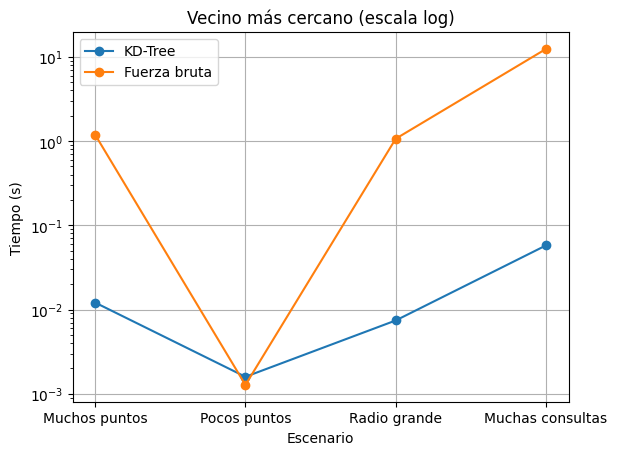

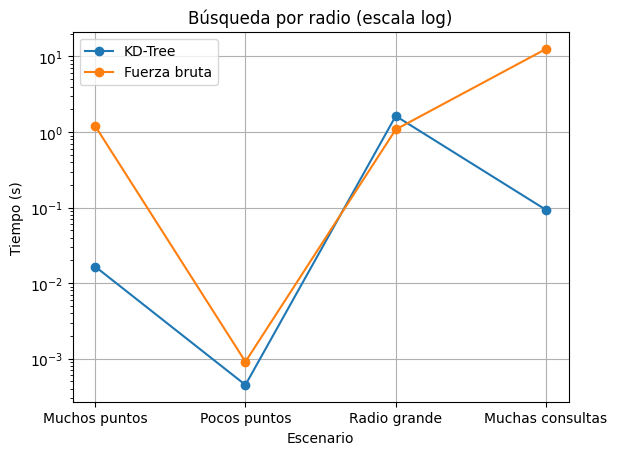

In [ ]:
import matplotlib.pyplot as plt

labels = ["Muchos puntos", "Pocos puntos", "Radio grande", "Muchas consultas"]

kd_cercano = [0.012090, 0.001589, 0.007417, 0.057767]
fb_cercano = [1.191894, 0.001272, 1.068201, 12.451668]

kd_radio = [0.016609, 0.000450, 1.630844, 0.093325]
fb_radio = [1.206648, 0.000912, 1.081840, 12.597067]


# =========================
# Vecino más cercano
# =========================
plt.figure()

plt.plot(labels, kd_cercano, marker='o', label="KD-Tree")
plt.plot(labels, fb_cercano, marker='o', label="Fuerza bruta")

plt.yscale('log')
plt.title("Vecino más cercano (escala log)")
plt.xlabel("Escenario")
plt.ylabel("Tiempo (s)")
plt.legend()
plt.grid()

plt.show()


# =========================
# Búsqueda por radio
# =========================
plt.figure()

plt.plot(labels, kd_radio, marker='o', label="KD-Tree")
plt.plot(labels, fb_radio, marker='o', label="Fuerza bruta")

plt.yscale('log')

plt.title("Búsqueda por radio (escala log)")
plt.xlabel("Escenario")
plt.ylabel("Tiempo (s)")
plt.legend()
plt.grid()

plt.show()

### **ANÁLISIS**

**Muchos puntos (10000):**  
El KD-Tree es mucho más rápido que fuerza bruta porque evita revisar todos los puntos. Gracias a la estructura del árbol y la poda, solo explora las regiones que podrían contener resultados. En cambio, fuerza bruta siempre recorre los 10000 puntos en cada consulta, lo que hace que el tiempo crezca considerablemente. Aquí se evidencia claramente la ventaja del KD-Tree cuando el tamaño de los datos es grande.

**Pocos puntos (10):**  
En este caso la diferencia es mínima e incluso fuerza bruta puede ser ligeramente más rápida. Esto ocurre porque el KD-Tree tiene un costo adicional debido a la recursión y la navegación en la estructura del árbol. Con tan pocos puntos, recorrerlos directamente es más simple y eficiente. Es decir, el KD-Tree no compensa su complejidad cuando el problema es pequeño.

**Radio grande (50000):**  
Aquí el KD-Tree pierde su principal ventaja, que es la poda. Como el radio es muy grande, prácticamente todos los puntos caen dentro del área de búsqueda, por lo que el algoritmo no puede descartar ramas del árbol. En consecuencia, termina recorriendo casi todos los nodos, de forma similar a fuerza bruta, pero con mayor sobrecosto debido a la recursión. Por esta razón, en este caso es más lento.

**Muchas consultas (1000):**  
El KD-Tree muestra su mejor rendimiento cuando hay muchas consultas. Aunque construir el árbol tiene un costo inicial, luego cada búsqueda es eficiente. Esto hace que el tiempo total sea mucho menor que fuerza bruta, que debe repetir el proceso completo para cada consulta. En este escenario, la diferencia de rendimiento es significativa.

**Conclusión:**  
El KD-Tree es eficiente cuando hay muchos datos y muchas consultas, especialmente si el radio de búsqueda no es demasiado grande. Su ventaja proviene de evitar revisar todos los puntos mediante poda. Sin embargo, no siempre es la mejor opción: con pocos datos o radios muy grandes, pierde eficiencia y puede ser igual o peor que fuerza bruta.